LAB 5


1. Thresholding để phân đoạn ảnh

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

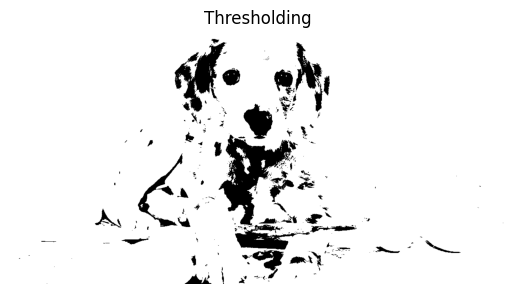

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

Quan.imshow(thresh, cmap='gray')
Quan.title("Thresholding")
Quan.axis('off')

2. Otsu algorithm để phân đoạn ảnh vân tay 

(np.float64(-0.5), np.float64(899.5), np.float64(595.5), np.float64(-0.5))

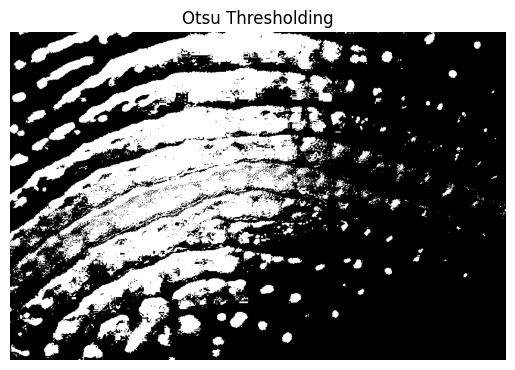

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('vantay.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, otsu = cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

Quan.imshow(otsu, cmap='gray')
Quan.title("Otsu Thresholding")
Quan.axis('off')

3. Clustering techniques trong phân đoạn ảnh, K-mean clustering

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

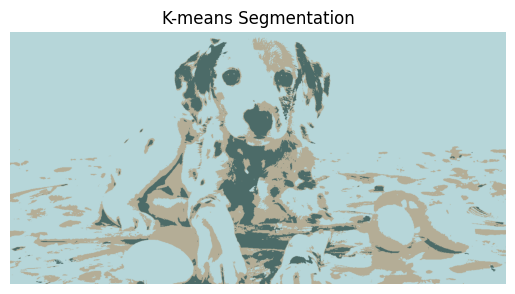

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Z = img.reshape((-1,3))
Z = np.float32(Z)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,10,1.0)

K = 3
ret,label,center = cv2.kmeans(Z,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
result = res.reshape((img.shape))

Quan.imshow(result)
Quan.title("K-means Segmentation")
Quan.axis('off')

4. Sử dụng thuật toán Region growing

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

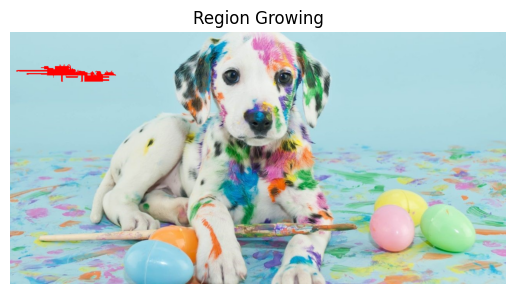

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]
mask = np.zeros((h+2, w+2), np.uint8)

seed = (100,100)

cv2.floodFill(img, mask, seed, (255,0,0))

Quan.imshow(img)
Quan.title("Region Growing")
Quan.axis('off')

5. Sử dụng thuật toán Split and merge để phân đoạn ảnh

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

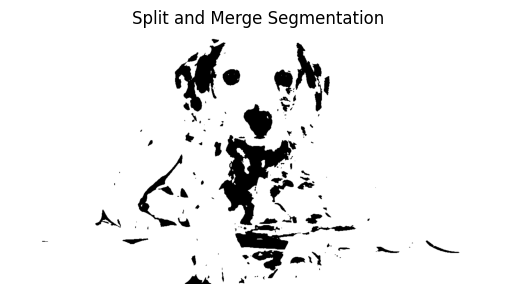

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray,(5,5),0)
ret,thresh = cv2.threshold(blur,128,255,cv2.THRESH_BINARY)

Quan.imshow(thresh,cmap='gray')
Quan.title("Split and Merge Segmentation")
Quan.axis('off')

6. Phân đoạn ảnh với Edge-based sigmentation

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

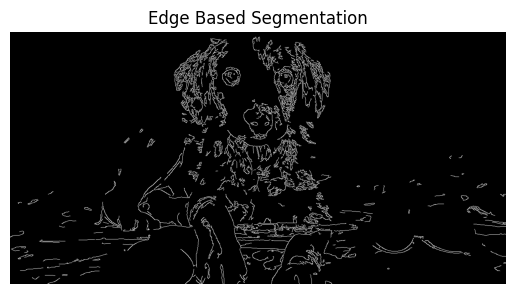

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as Quan

img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray,100,200)

Quan.imshow(edges,cmap='gray')
Quan.title("Edge Based Segmentation")
Quan.axis('off')

LAB 6

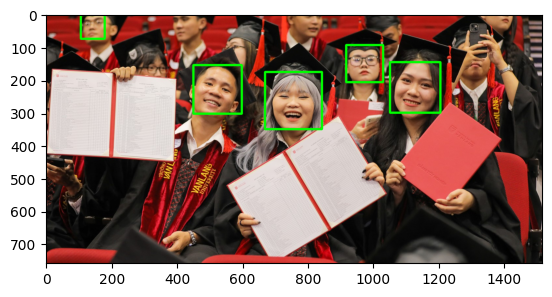

In [5]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("Image.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# dots that would look like STOP signs
stop_data = cv2.CascadeClassifier('haarcascade_frontalface_alt.xml') #('/content/haarcascade_frontalcatface.xml')
found = stop_data.detectMultiScale(img_gray,minSize =(20, 20))
amount_found = len(found)

if amount_found != 0:
    for (x, y, width, height) in found:
        cv2.rectangle(img_rgb, (x, y),
                      (x + height, y + width),
                      (0, 255, 0), 5)
plt.imshow(img_rgb)


2. Nhận diện 


Phát hiện được 4 khuôn mặt.


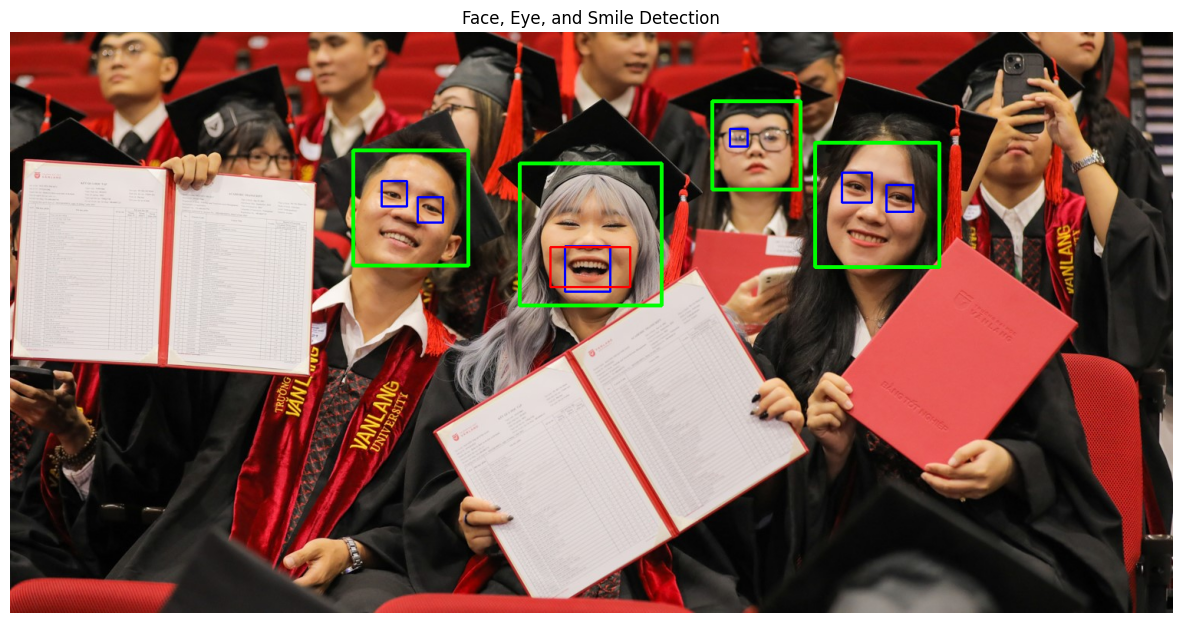

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = 'Image.jpg' 
img = cv2.imread(image_path)                                                                                                                                   
if img is None:
    print("Không tìm thấy ảnh. Vui lòng kiểm tra lại đường dẫn!")
else:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')
    smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')

    # 3. Nhận diện khuôn mặt trên toàn bộ ảnh xám
    # scaleFactor và minNeighbors có thể tinh chỉnh tùy thuộc vào độ lớn của mặt trong ảnh
    faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    print(f"Phát hiện được {len(faces)} khuôn mặt.")

    # 4. Duyệt qua từng khuôn mặt tìm được
    for (x, y, w, h) in faces:
        # Vẽ khung chữ nhật quanh khuôn mặt (Màu Xanh lá cây, độ dày 3)
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)

        # Tạo ROI (Region of Interest) cho phần khuôn mặt
        # Chúng ta chỉ tìm mắt và nụ cười BÊN TRONG khu vực khuôn mặt này
        roi_gray = img_gray[y:y+h, x:x+w]
        roi_rgb = img_rgb[y:y+h, x:x+w]

        # Nhận diện Mắt 
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10)
        for (ex, ey, ew, eh) in eyes:
            # Vẽ khung chữ nhật quanh mắt (Màu Xanh dương) trên roi_rgb
            cv2.rectangle(roi_rgb, (ex, ey), (ex + ew, ey + eh), (0, 0, 255), 2)

        # Nhận diện Nụ cười
        # Nụ cười thường khó nhận diện chính xác hơn, nên cần tăng scaleFactor và minNeighbors
        smiles = smile_cascade.detectMultiScale(roi_gray, scaleFactor=1.7, minNeighbors=20)
        for (sx, sy, sw, sh) in smiles:
            # Vẽ khung chữ nhật quanh nụ cười (Màu Đỏ)
            cv2.rectangle(roi_rgb, (sx, sy), (sx + sw, sy + sh), (255, 0, 0), 2)

    # 5. Hiển thị kết quả
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    plt.title('Face, Eye, and Smile Detection')
    plt.axis('off') # Tắt trục tọa độ cho đẹp
    plt.show()